Mean Squared Error: 26.782523432699985
R2 Score: 0.6347860115964862

Feature Importance:
          Coefficient
RM          4.776817
LSTAT      -0.593496
PTRATIO    -0.948690
INDUS       0.065783
NOX        -8.650123
AGE         0.032273


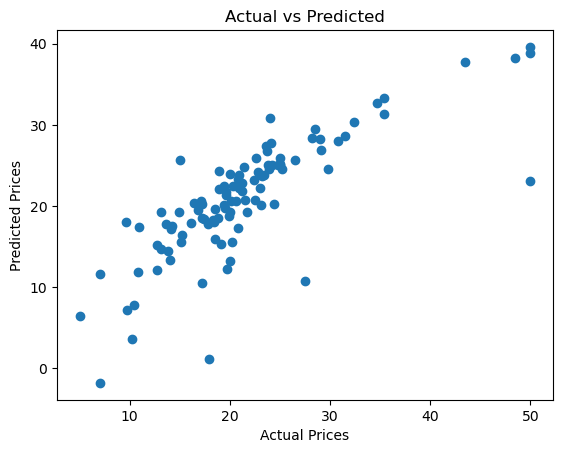

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv(r'C:\Users\pinky\Boston.csv')

df.columns = df.columns.str.strip()

df = df.drop(columns=[
    'CRIM', 'ZN', 'CHAS', 'DIS', 'RAD', 'TAX', 'B'
], errors='ignore')

df = df.dropna()

X = df[['RM', 'LSTAT', 'PTRATIO', 'INDUS', 'NOX', 'AGE']]
y = df['MEDV']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

coeff_df = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print("\nFeature Importance:\n", coeff_df)

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted")
plt.show()